# EDA : Kings County, Jacob Phillips
![](https://images.unsplash.com/photo-1618890187352-8e9d6b96b948?q=80&w=3106&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D)

### The purpose of this project is to explore data around Kings County housing adn use it to suggest property to satisfy the request of our client, Jacob Phillips. 

##### The process consisted of: 

1. Data preparation and exploration
2. Building hypothesis around correlations of data
3. Model diagnostics and visualising results
3. Building a suggestion portfolio

## Step 1: Data preparation and cleanup

In [ ]:
# Importing datasets and conducting preliminary view of the data

import warnings

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {"figure.figsize": (8, 5), "axes.facecolor": "white", "axes.edgecolor": "black"}
)
plt.rcParams["figure.facecolor"] = "w"
pd.plotting.register_matplotlib_converters()
pd.set_option("display.float_format", lambda x: "%.3f" % x)

df = pd.read_csv("data/eda.csv")

df.info


<bound method DataFrame.info of                id  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
0      7129300520     3.000      1.000     1180.000  5650.000   1.000   
1      6414100192     3.000      2.250     2570.000  7242.000   2.000   
2      5631500400     2.000      1.000      770.000 10000.000   1.000   
3      2487200875     4.000      3.000     1960.000  5000.000   1.000   
4      1954400510     3.000      2.000     1680.000  8080.000   1.000   
...           ...       ...        ...          ...       ...     ...   
21592   263000018     3.000      2.500     1530.000  1131.000   3.000   
21593  6600060120     4.000      2.500     2310.000  5813.000   2.000   
21594  1523300141     2.000      0.750     1020.000  1350.000   2.000   
21595   291310100     3.000      2.500     1600.000  2388.000   2.000   
21596  1523300157     2.000      0.750     1020.000  1076.000   2.000   

       waterfront  view  condition  grade  ...  sqft_basement  yr_built  \
0             Na

In [119]:
df = pd.read_csv("data/eda.csv")
df.head()


,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
0,7129300520,3.000,1.000,1180.000,5650.000,1.000,NaN,0.000,3,7,...,0.000,1955,0.000,98178,47.511,-122.257,1340.000,5650.000,2014-10-13,221900.000
1,6414100192,3.000,2.250,2570.000,7242.000,2.000,0.000,0.000,3,7,...,400.000,1951,19910.000,98125,47.721,-122.319,1690.000,7639.000,2014-12-09,538000.000
2,5631500400,2.000,1.000,770.000,10000.000,1.000,0.000,0.000,3,6,...,0.000,1933,NaN,98028,47.738,-122.233,2720.000,8062.000,2015-02-25,180000.000
3,2487200875,4.000,3.000,1960.000,5000.000,1.000,0.000,0.000,5,7,...,910.000,1965,0.000,98136,47.521,-122.393,1360.000,5000.000,2014-12-09,604000.000
4,1954400510,3.000,2.000,1680.000,8080.000,1.000,0.000,0.000,3,8,...,0.000,1987,0.000,98074,47.617,-122.045,1800.000,7503.000,2015-02-18,510000.000


### Data cleanup 

In [120]:
# Convert bedrooms to integer (removes the .000 entirely)
df['bedrooms'] = df['bedrooms'].astype(int)
# Convert floors to integer (removes the .000 entirely)
df['floors'] = df['floors'].astype(int)



# Fill 0 instead of NaN to fix missing data 
df['yr_renovated'] = df['yr_renovated'].fillna(0)
df['waterfront'] = df['waterfront'].fillna(0)
df['sqft_basement'] = df['sqft_basement'].fillna(0)
df['view'] = df['view'].fillna(0)

# Convert waterfront and view to integer (removes the .000 entirely)
df['waterfront'] = df['waterfront'].astype(int)
df['view'] = df['view'].astype(int)

# Convert year renovated to integer + fix the mistake in format writing 
df["yr_renovated"] = df["yr_renovated"].apply(
    lambda x: x / 10 if x > 9999 else x
)
df['yr_renovated'] = df['yr_renovated'].astype(int)

# Round to .xx and only show .xx for the whole dataframe
df = df.round(2)
pd.set_option("display.float_format", lambda x: "%.2f" % x)

df.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
0,7129300520,3,1.00,1180.00,5650.00,1,0,0,3,7,...,0.00,1955,0,98178,47.51,-122.26,1340.00,5650.00,2014-10-13,221900.00
1,6414100192,3,2.25,2570.00,7242.00,2,0,0,3,7,...,400.00,1951,1991,98125,47.72,-122.32,1690.00,7639.00,2014-12-09,538000.00
2,5631500400,2,1.00,770.00,10000.00,1,0,0,3,6,...,0.00,1933,0,98028,47.74,-122.23,2720.00,8062.00,2015-02-25,180000.00
3,2487200875,4,3.00,1960.00,5000.00,1,0,0,5,7,...,910.00,1965,0,98136,47.52,-122.39,1360.00,5000.00,2014-12-09,604000.00
4,1954400510,3,2.00,1680.00,8080.00,1,0,0,3,8,...,0.00,1987,0,98074,47.62,-122.04,1800.00,7503.00,2015-02-18,510000.00


In [121]:
df.describe()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,price
count,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00
mean,4580474287.77,3.37,2.12,2080.32,15099.41,1.45,0.01,0.23,3.41,7.66,1788.60,285.75,1971.00,68.76,98077.95,47.56,-122.21,1986.62,12758.28,540296.57
std,2876735715.75,0.93,0.77,918.11,41412.64,0.55,0.08,0.76,0.65,1.17,827.76,439.82,29.38,364.04,53.51,0.14,0.14,685.23,27274.44,367368.14
min,1000102.00,1.00,0.50,370.00,520.00,1.00,0.00,0.00,1.00,3.00,370.00,0.00,1900.00,0.00,98001.00,47.16,-122.52,399.00,651.00,78000.00
25%,2123049175.00,3.00,1.75,1430.00,5040.00,1.00,0.00,0.00,3.00,7.00,1190.00,0.00,1951.00,0.00,98033.00,47.47,-122.33,1490.00,5100.00,322000.00
50%,3904930410.00,3.00,2.25,1910.00,7618.00,1.00,0.00,0.00,3.00,7.00,1560.00,0.00,1975.00,0.00,98065.00,47.57,-122.23,1840.00,7620.00,450000.00
75%,7308900490.00,4.00,2.50,2550.00,10685.00,2.00,0.00,0.00,4.00,8.00,2210.00,550.00,1997.00,0.00,98118.00,47.68,-122.12,2360.00,10083.00,645000.00
max,9900000190.00,33.00,8.00,13540.00,1651359.00,3.00,1.00,4.00,5.00,13.00,9410.00,4820.00,2015.00,2015.00,98199.00,47.78,-121.32,6210.00,871200.00,7700000.00


#### Lets's plot all the data to get the better understanding of the distribution

array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'bedrooms'}>,
        <Axes: title={'center': 'bathrooms'}>,
        <Axes: title={'center': 'sqft_living'}>],
       [<Axes: title={'center': 'sqft_lot'}>,
        <Axes: title={'center': 'floors'}>,
        <Axes: title={'center': 'waterfront'}>,
        <Axes: title={'center': 'view'}>],
       [<Axes: title={'center': 'condition'}>,
        <Axes: title={'center': 'grade'}>,
        <Axes: title={'center': 'sqft_above'}>,
        <Axes: title={'center': 'sqft_basement'}>],
       [<Axes: title={'center': 'yr_built'}>,
        <Axes: title={'center': 'yr_renovated'}>,
        <Axes: title={'center': 'zipcode'}>,
        <Axes: title={'center': 'lat'}>],
       [<Axes: title={'center': 'long'}>,
        <Axes: title={'center': 'sqft_living15'}>,
        <Axes: title={'center': 'sqft_lot15'}>,
        <Axes: title={'center': 'price'}>]], dtype=object)

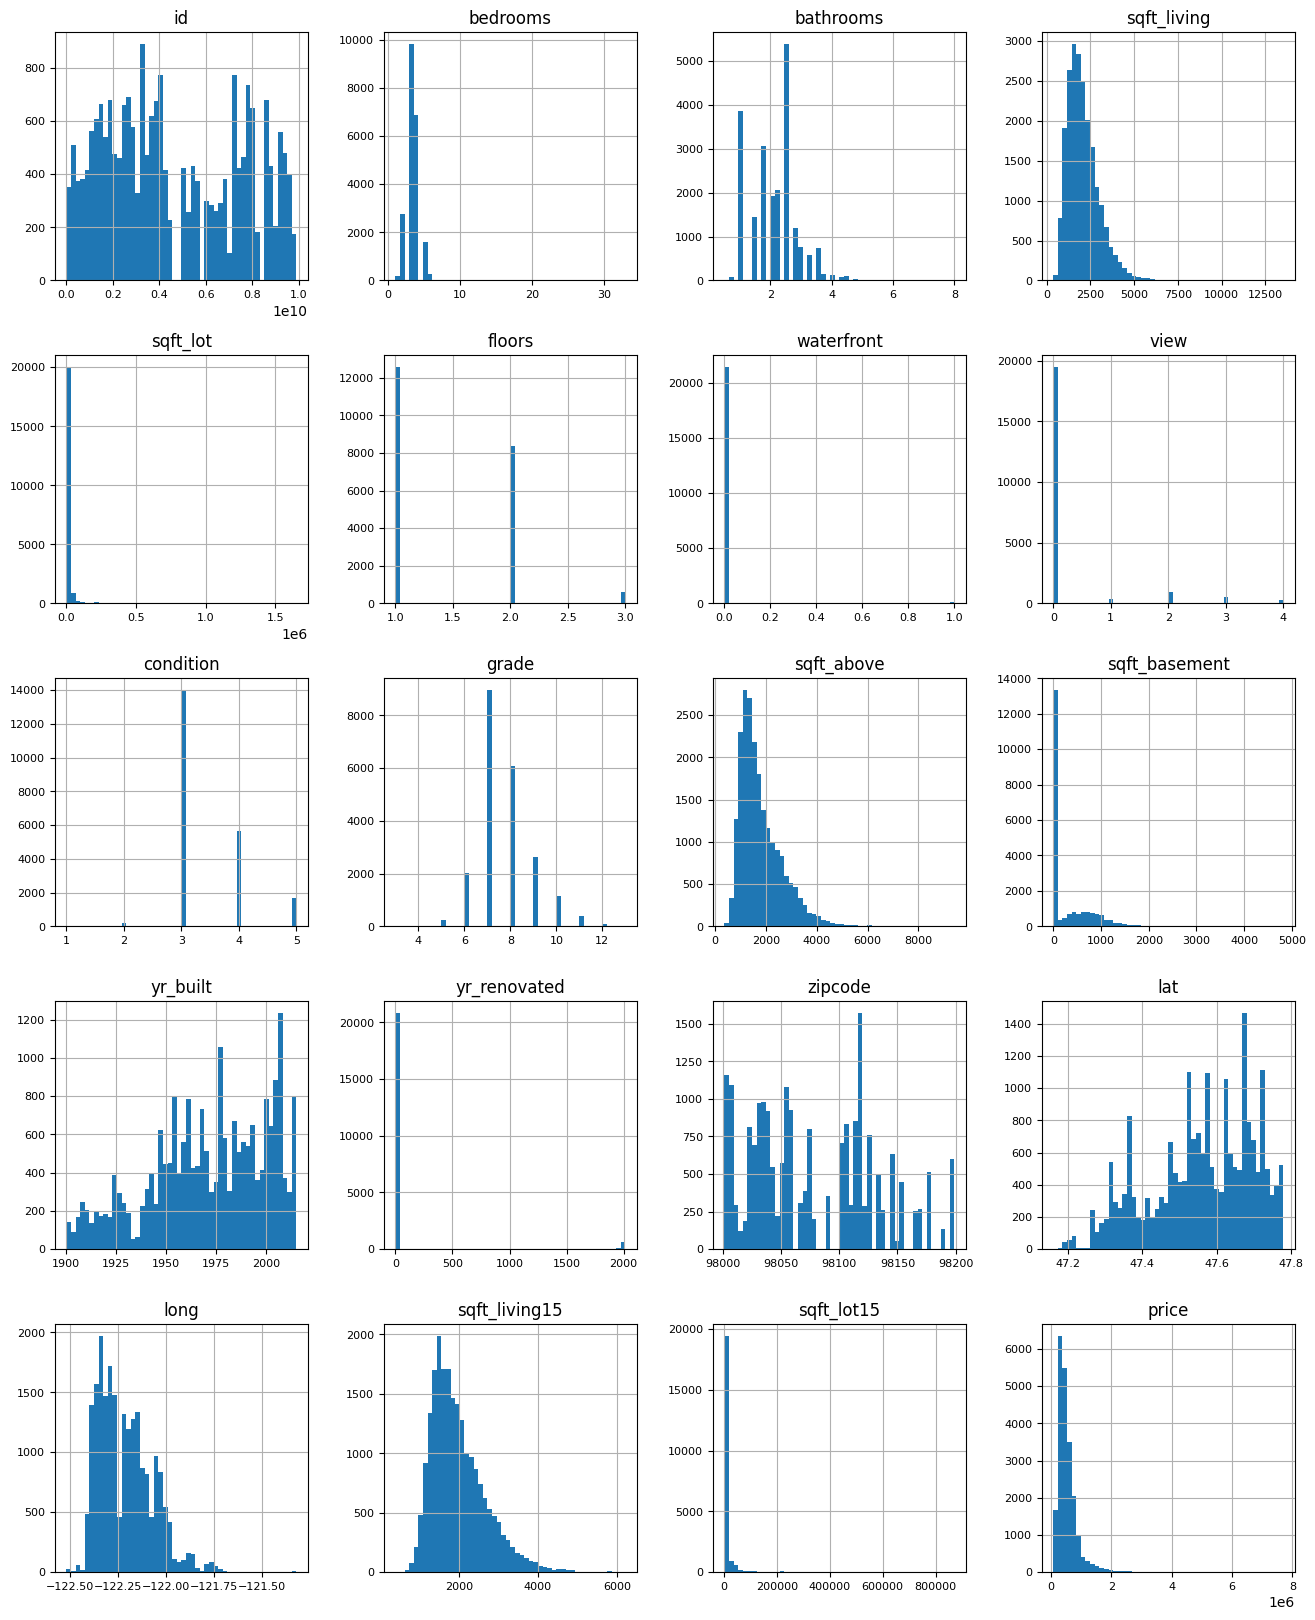

In [ ]:
df.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8)

#### Finding the features most correlated with the price of the houses 

In [ ]:
df_num = df.select_dtypes(include = ['float64', 'int64'])

df_num = df_num.corr()['price'][:-1] # -1 because the latest row is SalePrice
golden_features_list = df_num[abs(df_num) > 0.5].sort_values(ascending=False)
print("There is {} strongly correlated values with Sale Price:\n{}".format(len(golden_features_list), golden_features_list))

There is 5 strongly correlated values with SalePrice:
sqft_living     0.70
grade           0.67
sqft_above      0.61
sqft_living15   0.59
bathrooms       0.53
Name: price, dtype: float64


#### Building Scatter-plot of the 5 most correlated ones

['id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'price']


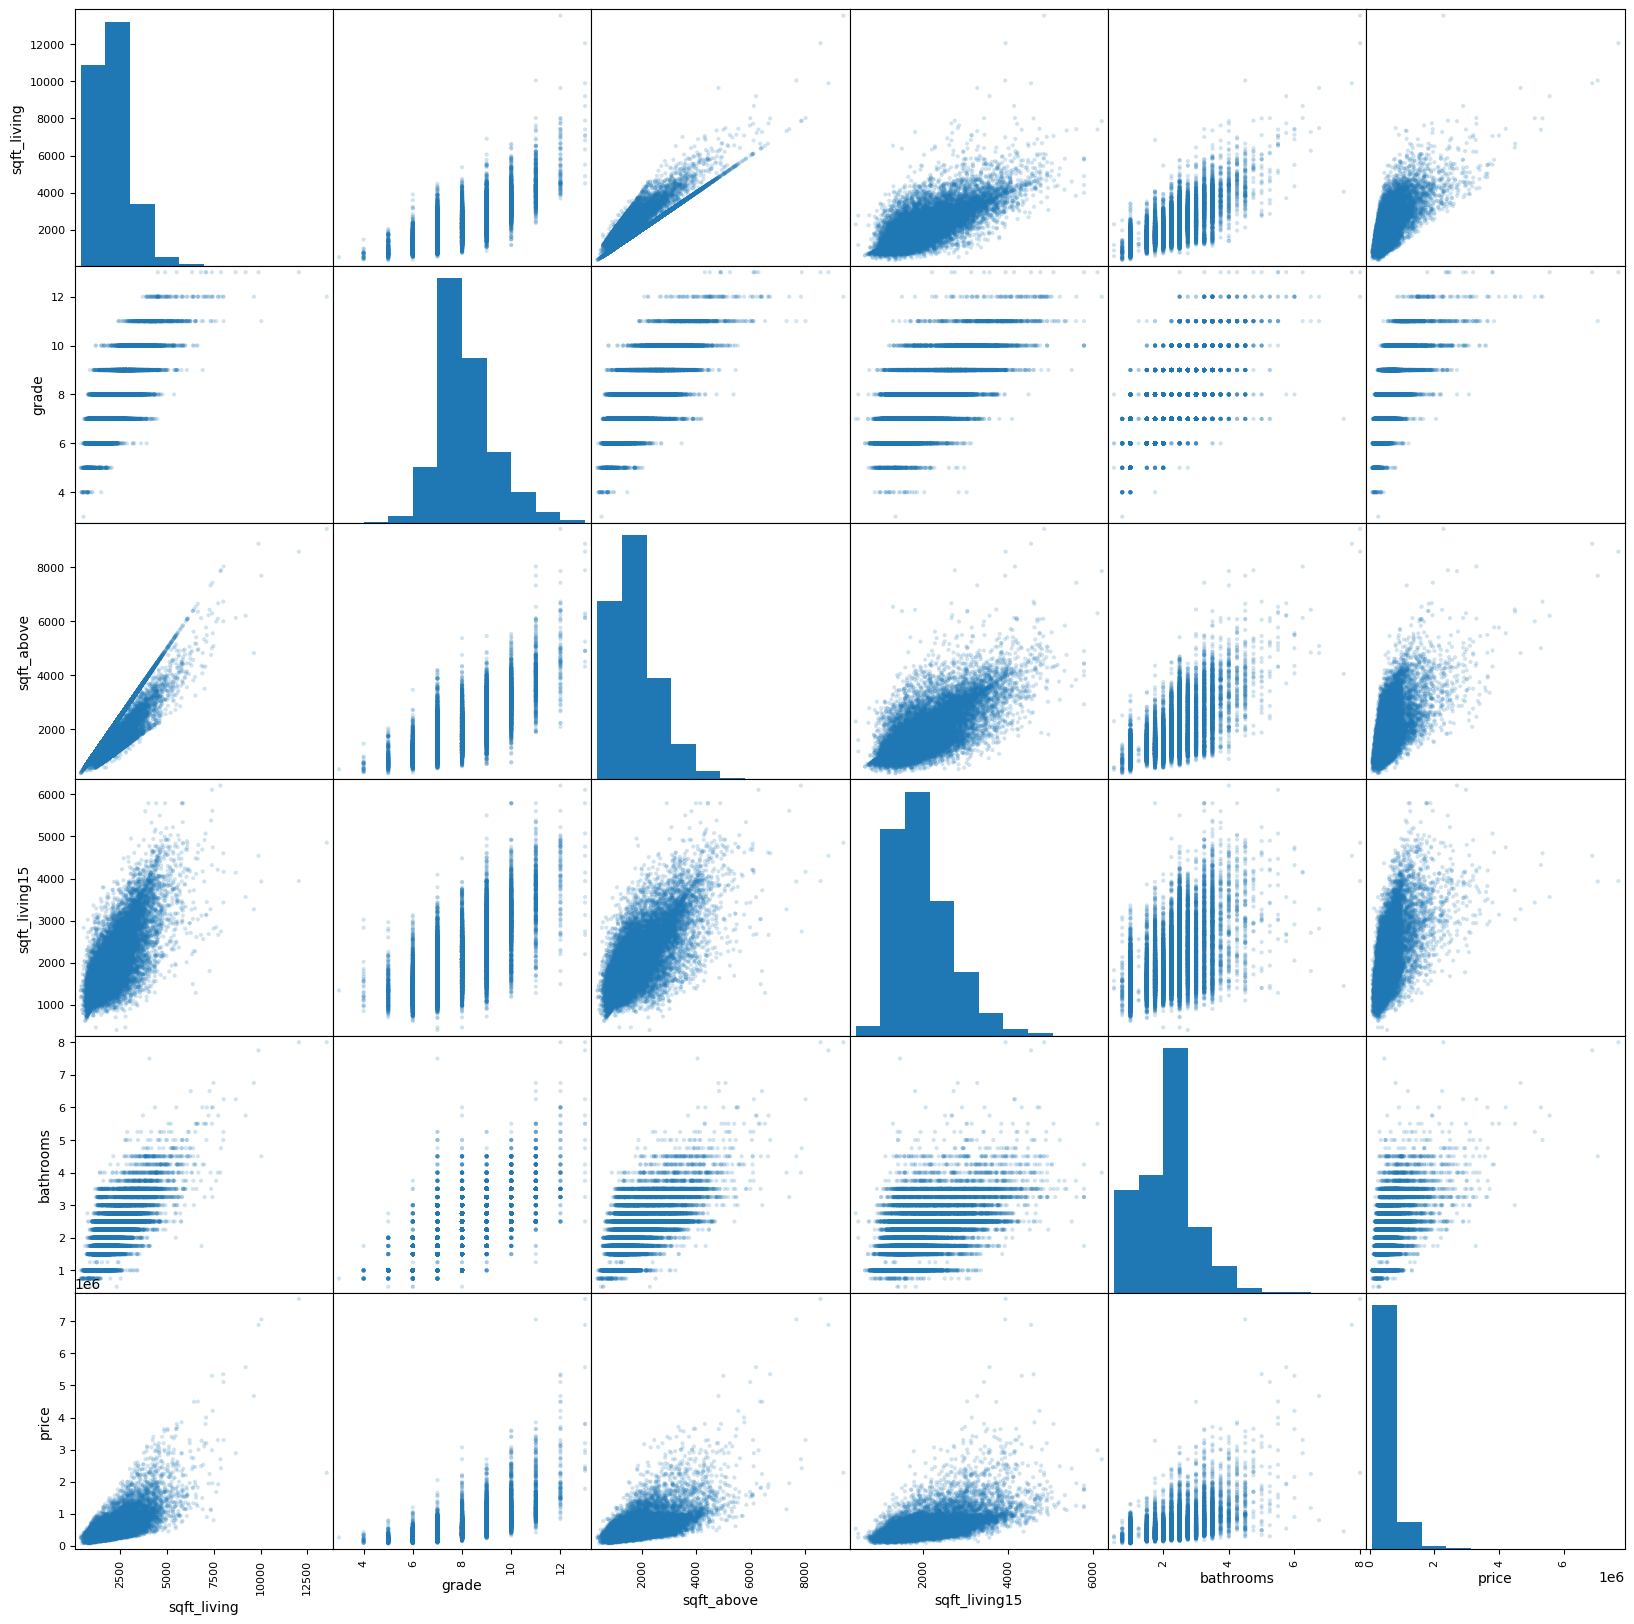

In [ ]:
from pandas.plotting import scatter_matrix

df_num = df.select_dtypes(include=['float64', 'int64'])
print(df_num.columns.tolist())
cols = golden_features_list.index.tolist() + ['price']
scatter_matrix(df_num[cols], figsize=(20, 20), alpha=0.2, diagonal='hist')
plt.show()




-------------



## Organized search for house locations that satisfy being historic and that have a golf course nearby

There are around 30 golf courses in King County, WA. A raw list of golf courses and their locations (coordinates or zip codes) will be not an effective filter since among the requirements, the buyer also wants a house that is in a historic area. Most golf courses will be in the suburbs. 

For maximal effectiveness in the search, we can narrow down the areas that are historic, and that have a nearby golf course.

The final data to be used as filter, is a list of zip codes that satisfy both conditions. That ZIP code can be used directly as a filter to the dataframe. 

Rather than Data Engineering, this is best done via searches in the internet and with AI tools.

An initial search via AI provides these zip codes with Golf Courses, that are located in districts that can be characterized as historic. The qualification as 'historic' is fuzzy and subject to interpretation - like having historic landmarks for example, and not a part of an 'official' historic-zipcode list. 

In [102]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

In [103]:
# add the commands here to show the contents of king_county_historic_golf_zips.csv
df_golfzips = pd.read_csv("king_county_historic_golf_zips.csv")
df_golfzips.head(14)

,zipcode,area_name,golf_course_name,why_historic
0,98118,"Columbia City, Seattle",Bill Wright Golf Complex (Jefferson Park),One of Seattle's eight officially designated h...
1,98144,"Mount Baker, Seattle",Bill Wright Golf Complex (Jefferson Park),Olmsted-planned early-20th-century streetcar n...
2,98108,"Beacon Hill, Seattle",Bill Wright Golf Complex (Jefferson Park),Contains the Olmsted Brothers-designed Jeffers...
3,98107,"Ballard, Seattle",Interbay Golf Center,Ballard Avenue Historic District is on the Nat...
4,98116,West Seattle (Admiral/Alki),West Seattle Golf Course,"Historic Admiral district and Alki Point, site..."
5,98126,West Seattle (Golf/Genesee),West Seattle Golf Course,Adjacent ZIP containing the municipal course (...
6,98125,Maple Leaf / North Seattle,Jackson Park Golf Course,Older north-Seattle housing stock near the his...
7,98065,Snoqualmie,Mount Si Golf Course,Historic downtown Snoqualmie and Snoqualmie Fa...
8,98022,Enumclaw,Enumclaw Golf Course,Historic early-1900s small-town downtown found...
9,98010,Black Diamond,"Lake Wilderness Golf Course (Maple Valley, 98038)",National Register-listed former coal-mining to...


In [104]:
# Let's pick houses older than 1920 and form a dataframe with them

df_historical = df[df['yr_built'] < 1920]
df_historical.head()
df_historical.describe()

# WOW!! it's actually 1450 houses, a lot


# And build a dataframe for Jacob's request

df_proposal = df_historical[df_historical['waterfront'] == 0]
df_proposal.head()
df_proposal.shape[0]
# That's just 1441 that are not waterfront, also shocking info. I thought proportion would be different


df_proposal = df_proposal[df_proposal['bathrooms'] >= 4]
df_proposal.head()
df_proposal.shape[0]
# After bathroom count filter we have 17 results


# Checking for the size over 80000
#df_proposal = df_proposal[df_proposal['sqft_lot'] >= 80000]

# There is none for such request. So I'll just sort descending
df_proposal = df_proposal.sort_values('sqft_lot', ascending=False)
df_proposal.head(17)

# Create a list of zipcodes filtered for golf course related request
# See where they overlap
df_proposal = df_proposal[df_proposal['zipcode'].isin(df_golfzips['zipcode'])]
df_proposal.shape[0]

# Got 5!




5

## The 5 houses to suggest: 

In [105]:
df_proposal.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
5961,5249800010,4,4.25,6410.00,43838.00,2,0,2,4,12,...,800.00,1906,0,98144,47.57,-122.28,2270.00,6630.00,2014-12-03,2730000.00
9405,5700003630,5,4.25,4830.00,8050.00,2,0,0,4,11,...,1120.00,1914,0,98144,47.58,-122.29,4470.00,9194.00,2014-06-30,1930000.00
15346,1175000280,4,4.00,1550.00,6596.00,1,0,0,5,7,...,0.00,1907,0,98107,47.67,-122.40,1830.00,4850.00,2014-11-07,707500.00
3582,9272200090,4,4.50,3780.00,6000.00,2,0,4,4,11,...,1010.00,1910,1977,98116,47.59,-122.39,2660.00,6000.00,2015-02-04,1600000.00
6665,475001235,5,4.00,3400.00,5000.00,2,0,0,3,8,...,1080.00,1900,2013,98107,47.67,-122.36,1910.00,5000.00,2014-08-08,870000.00


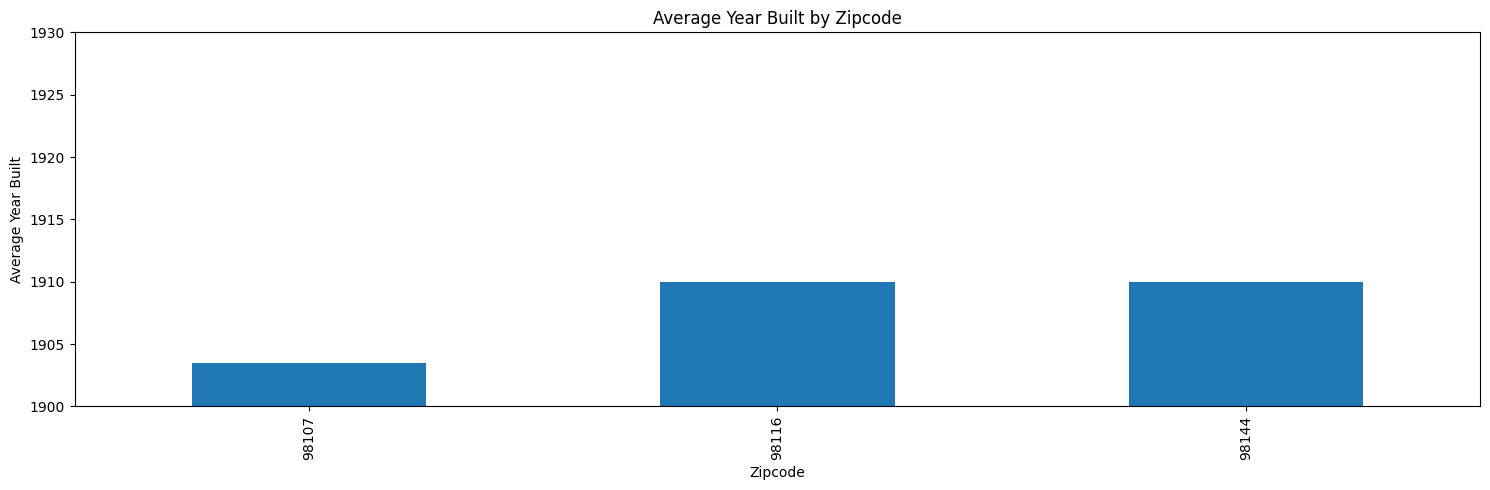

In [106]:
# Build a chart to see suggested houses per zipcodes

df_proposal.groupby('zipcode')['yr_built'].mean().round().astype(int)
# Build a histogram to visualize this metric now
df_proposal.groupby('zipcode')['yr_built'].mean().plot(kind='bar', figsize=(15, 5))
plt.xlabel('Zipcode')
plt.ylabel('Average Year Built')
plt.title('Average Year Built by Zipcode')
plt.tight_layout()
plt.ylim(1900, 1930)
plt.show()

## Hypotheses

1. GEO - ZIP codes with waterfront will have higher price per sqft on avg than those away from the water, within city limits.
Counters - port city, cold, humidity can be a negative - can be that places in high altitude neighborhoods fetch better prices.

2. Amount of bathrooms correlates with how historical the area is. To double proof the historical value of the neighhbourghood: overlap charts of age of housing in the neigbhbourghood (average age built per zipcode) and zipcodes we picked. Then see avg amount of bathrommns per each



3. Year built will correlate with value, older non-renovated houses will have lower persqft value.
[This may also be a curve, as some classic houses may be in classic locations instead of edge of the city.]

### Hypothesis 1

In [107]:
# Let's start with picking out houses with waterfront
df_waterfront = df[df['waterfront']>0]
df_waterfront.shape

df['px_per_sqft'] = df['price'] / df['sqft_living']
df.head()


,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,px_per_sqft
0,7129300520,3,1.00,1180.00,5650.00,1,0,0,3,7,...,1955,0,98178,47.51,-122.26,1340.00,5650.00,2014-10-13,221900.00,188.05
1,6414100192,3,2.25,2570.00,7242.00,2,0,0,3,7,...,1951,1991,98125,47.72,-122.32,1690.00,7639.00,2014-12-09,538000.00,209.34
2,5631500400,2,1.00,770.00,10000.00,1,0,0,3,6,...,1933,0,98028,47.74,-122.23,2720.00,8062.00,2015-02-25,180000.00,233.77
3,2487200875,4,3.00,1960.00,5000.00,1,0,0,5,7,...,1965,0,98136,47.52,-122.39,1360.00,5000.00,2014-12-09,604000.00,308.16
4,1954400510,3,2.00,1680.00,8080.00,1,0,0,3,8,...,1987,0,98074,47.62,-122.04,1800.00,7503.00,2015-02-18,510000.00,303.57


### Hypothesis 2

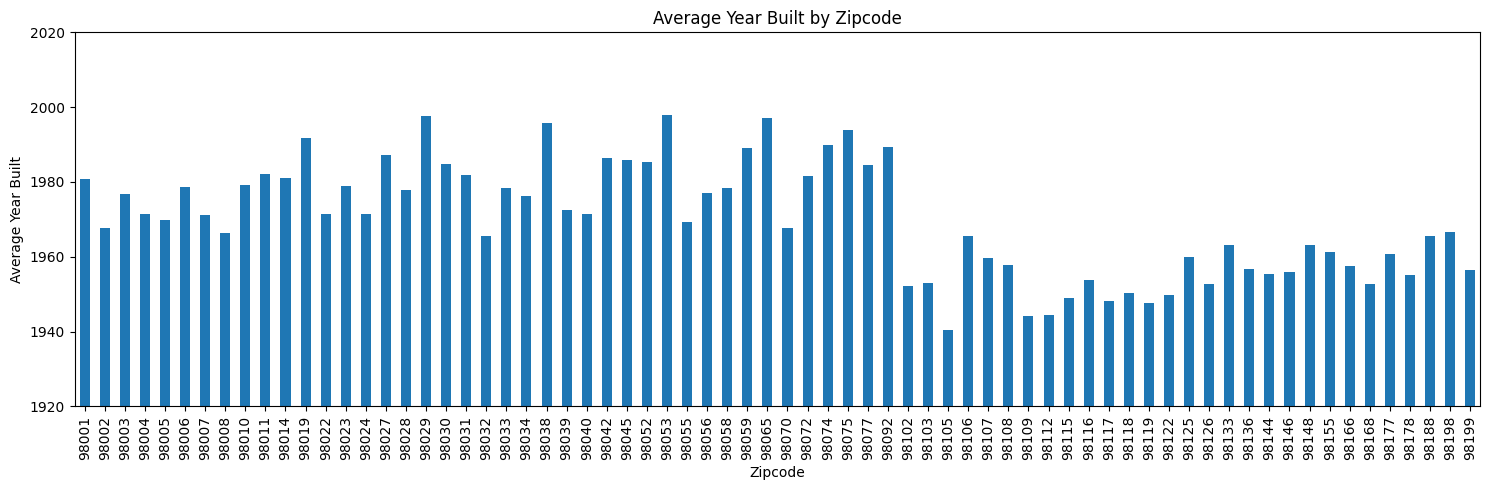

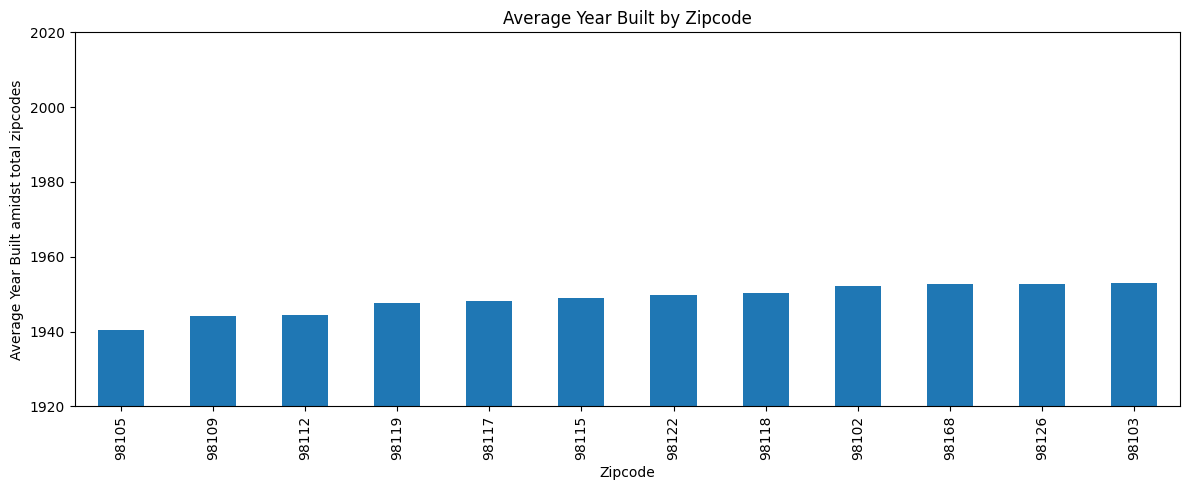

In [108]:
# Building a chart to see average age of built per zipcode




# Let's start from checking how many zipcodes are we talking about. 

# And calculating average year of built per zipcode
df.groupby('zipcode')['yr_built'].mean().round().astype(int)
# Build a histogram to visualize this metric now




df.groupby('zipcode')['yr_built'].mean().plot(kind='bar', figsize=(15, 5))
plt.xlabel('Zipcode')
plt.ylabel('Average Year Built')
plt.title('Average Year Built by Zipcode')
plt.tight_layout()
plt.ylim(1920, 2020)
plt.show()



df_historical_area = df.groupby('zipcode')['yr_built'].mean().sort_values(ascending=True)
df_historical_area.head(12).plot(kind='bar', figsize=(12, 5))
plt.xlabel('Zipcode')
plt.ylabel('Average Year Built amidst total zipcodes')
plt.title('Average Year Built by Zipcode')
plt.tight_layout()
plt.ylim(1920, 2020)
plt.show()




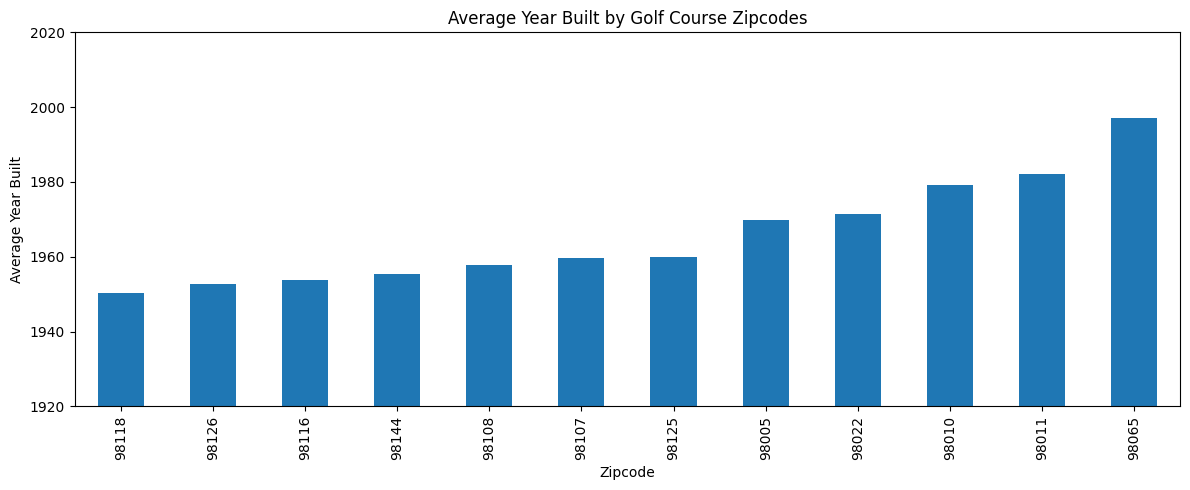

In [109]:
# Now the chart only for those zipcodes that are in golfzipz (Use this chart to show overlapping zipcodes)
df[df['zipcode'].isin(df_golfzips['zipcode'])].groupby('zipcode')['yr_built'].mean().sort_values(ascending=True).plot(kind='bar', figsize=(12, 5))
plt.xlabel('Zipcode')
plt.ylabel('Average Year Built')
plt.title('Average Year Built by Golf Course Zipcodes')
plt.tight_layout()
plt.ylim(1920, 2020)
plt.show()


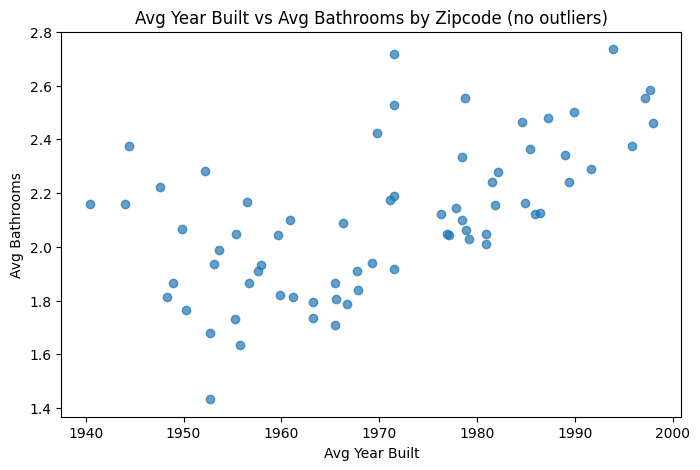

0.584243106183958


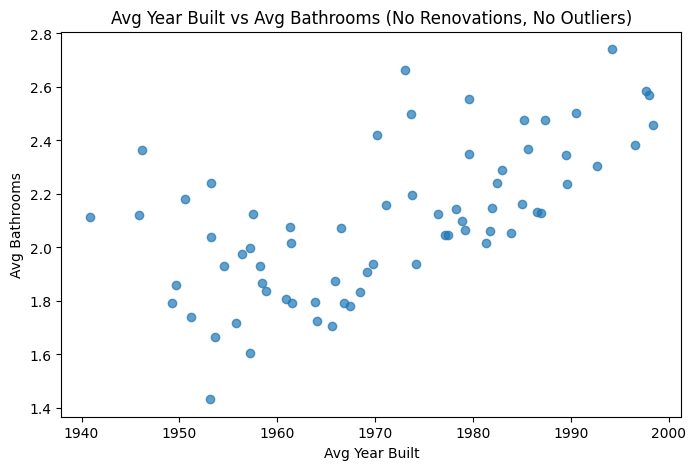

0.62989232035531


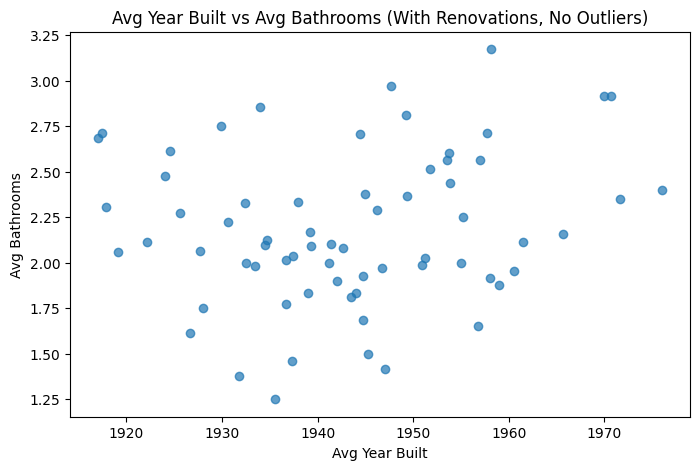

0.16689886700017748


In [110]:
# Now build a chart showing correlation between avg bathrooms and avg year built per area
df_zip = df.groupby('zipcode').agg(avg_bathrooms=('bathrooms', 'mean'), avg_yr_built=('yr_built', 'mean'))
Q1 = df_zip['avg_bathrooms'].quantile(0.25)
Q3 = df_zip['avg_bathrooms'].quantile(0.75)
IQR = Q3 - Q1

df_zip_clean = df_zip[(df_zip['avg_bathrooms'] >= Q1 - 1.5 * IQR) & 
                       (df_zip['avg_bathrooms'] <= Q3 + 1.5 * IQR)]

plt.scatter(df_zip_clean['avg_yr_built'], df_zip_clean['avg_bathrooms'], alpha=0.7)
plt.xlabel('Avg Year Built')
plt.ylabel('Avg Bathrooms')
plt.title('Avg Year Built vs Avg Bathrooms by Zipcode (no outliers)')
plt.show()

print(df_zip_clean['avg_yr_built'].corr(df_zip_clean['avg_bathrooms']))

# The trend exists (newer areas have more bathrooms) but it's not a reliable predictor on its own.


df_noreno = df[df['yr_renovated'] == 0]

df_zip_noreno = df_noreno.groupby('zipcode').agg(avg_bathrooms=('bathrooms', 'mean'), avg_yr_built=('yr_built', 'mean'))

#print(df_zip_noreno['avg_yr_built'].corr(df_zip_noreno['avg_bathrooms']))

Q1 = df_zip_noreno['avg_bathrooms'].quantile(0.25)
Q3 = df_zip_noreno['avg_bathrooms'].quantile(0.75)
IQR = Q3 - Q1

df_zip_noreno_clean = df_zip_noreno[(df_zip_noreno['avg_bathrooms'] >= Q1 - 1.5 * IQR) & 
                                     (df_zip_noreno['avg_bathrooms'] <= Q3 + 1.5 * IQR)]

plt.scatter(df_zip_noreno_clean['avg_yr_built'], df_zip_noreno_clean['avg_bathrooms'], alpha=0.7)
plt.xlabel('Avg Year Built')
plt.ylabel('Avg Bathrooms')
plt.title('Avg Year Built vs Avg Bathrooms (No Renovations, No Outliers)')
plt.show()

print(df_zip_noreno_clean['avg_yr_built'].corr(df_zip_noreno_clean['avg_bathrooms']))



df_reno = df[df['yr_renovated'] != 0]

df_zip_reno = df_reno.groupby('zipcode').agg(avg_bathrooms=('bathrooms', 'mean'), avg_yr_built=('yr_built', 'mean'))

#print(df_zip_noreno['avg_yr_built'].corr(df_zip_noreno['avg_bathrooms']))

Q1 = df_zip_reno['avg_bathrooms'].quantile(0.25)
Q3 = df_zip_reno['avg_bathrooms'].quantile(0.75)
IQR = Q3 - Q1

df_zip_reno_clean = df_zip_reno[(df_zip_reno['avg_bathrooms'] >= Q1 - 1.5 * IQR) & 
                                     (df_zip_reno['avg_bathrooms'] <= Q3 + 1.5 * IQR)]

plt.scatter(df_zip_reno_clean['avg_yr_built'], df_zip_reno_clean['avg_bathrooms'], alpha=0.7)
plt.xlabel('Avg Year Built')
plt.ylabel('Avg Bathrooms')
plt.title('Avg Year Built vs Avg Bathrooms (With Renovations, No Outliers)')
plt.show()

print(df_zip_reno_clean['avg_yr_built'].corr(df_zip_reno_clean['avg_bathrooms']))







No renovations housing is moderate-to-strong positive correlation (0.62) — stronger than the full dataset (0.58) and much stronger than non-renovated houses (0.40).

This confirms that renovations are driving the relationship: renovated older homes tend to have more bathrooms added, pushing the correlation up.

It's also interesting to see that there's a dip for the timeframe of 1960-1970, let;s investigate that

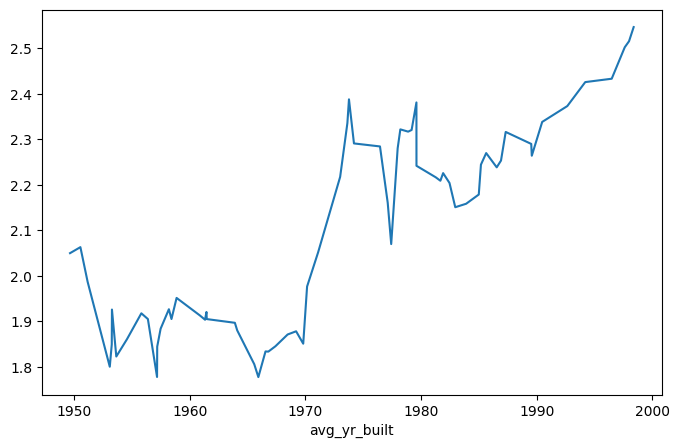

avg_bathrooms      1.43
avg_yr_built    1952.72
Name: 98168, dtype: float64


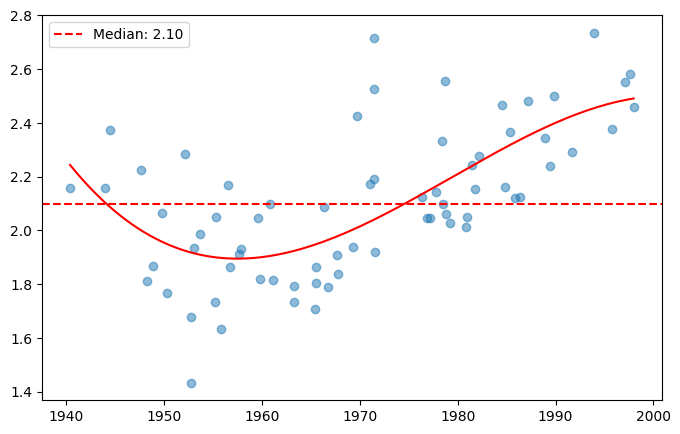

Dip bottom: 1953
Dip start: 1944
Dip end: 1989


In [111]:
# Rolling average — smooths the scatter to visually find the dip edges

df_zip_noreno.sort_values('avg_yr_built').set_index('avg_yr_built')['avg_bathrooms'].rolling(5).mean().plot()
plt.show()

# Find the local minimum — the bottom of the dip

df_sorted = df_zip_clean.sort_values('avg_yr_built')
min_idx = df_sorted['avg_bathrooms'].idxmin()
print(df_sorted.loc[min_idx])

#Polynomial regression — fits a curve and finds where it drops/rises

import numpy as np

x = df_zip_clean['avg_yr_built']
y = df_zip_clean['avg_bathrooms']

coeffs = np.polyfit(x, y, deg=3)
poly = np.poly1d(coeffs)

x_range = np.linspace(x.min(), x.max(), 300)
plt.scatter(x, y, alpha=0.5)
plt.plot(x_range, poly(x_range), color='red')
plt.axhline(df_zip_clean['avg_bathrooms'].median(), color='red', linestyle='--', label=f'Median: {df_zip_clean["avg_bathrooms"].median():.2f}')
plt.legend()
plt.show()


df_sorted = df_zip_clean.sort_values('avg_yr_built').reset_index()
rolling = df_sorted['avg_bathrooms'].rolling(5, center=True).mean()

# Find the bottom of the dip
min_idx = rolling.idxmin()
print(f"Dip bottom: {df_sorted.loc[min_idx, 'avg_yr_built']:.0f}")

# Find where it starts dropping and starts recovering
threshold = rolling.max() * 0.95  # 5% below peak = entering dip
dip_region = df_sorted[rolling < threshold]
print(f"Dip start: {dip_region['avg_yr_built'].min():.0f}")
print(f"Dip end: {dip_region['avg_yr_built'].max():.0f}")
